PROBLEM STATEMENT

Brain tumors are abnormal growths of cells in the brain that can severely affect brain function and overall health. Traditionally, brain tumor diagnosis is performed by radiologists through manual analysis of MRI images. However, this process can be time-consuming and may lead to inconsistencies due to human error, especially when handling a large number of medical images.With the advancement of artificial intelligence and deep learning, automated image classification systems can assist medical professionals in diagnosing diseases more efficiently. Convolutional Neural Networks (CNNs) are widely used in medical image analysis because they can automatically extract important spatial features from images without manual feature engineering.

The aim of this project is to develop a Brain Tumor Prediction Model using a Convolutional Neural Network (CNN) that can analyze MRI brain images and classify them into four categories: Glioma Tumor, Meningioma Tumor, Pituitary Tumor, and No Tumor. The model learns patterns and features from labeled MRI images during the training process and predicts the tumor type for new unseen images.

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [3]:
DATASET_PATH =r"C:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\data image"

In [5]:
# Image Data Genetators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1 #10% of training data for validation
)

#Training data
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH +"\\Training",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#Validation data
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

#Test data
test_datagen=ImageDataGenerator(rescale=1./255)
test_generator=test_datagen.flow_from_directory(
    DATASET_PATH + "\\Testing",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 5143 images belonging to 4 classes.
Found 569 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [8]:
# CNN Model
model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(512,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax') #4 classes:Glioma,Meningioma, Pituitary, No Tumor
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\Brain\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.fit(train_generator,validation_data=val_generator,epochs=30)

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 112s 695ms/step - accuracy: 0.9049 - loss: 0.2555 - val_accuracy: 0.8612 - val_loss: 0.4391
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 113s 700ms/step - accuracy: 0.9113 - loss: 0.2364 - val_accuracy: 0.8699 - val_loss: 0.4327
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 112s 692ms/step - accuracy: 0.9191 - loss: 0.2175 - val_accuracy: 0.8682 - val_loss: 0.4015
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 691ms/step - accuracy: 0.9230 - loss: 0.2159 - val_accuracy: 0.8629 - val_loss: 0.4456
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 112s 692ms/step - accuracy: 0.9248 - loss: 0.2084 - val_accuracy: 0.8647 - val_loss: 0.3928
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 114s 707ms/step - accuracy: 0.9238 - loss: 0.2107 - val_accuracy: 0.8594 - val_loss: 0.4551
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 112s 695ms/step - accuracy: 0.9345 - loss: 0.1858 - val_accuracy: 0.8981 - val_loss: 0.3404
Epoch 8/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 113s 703ms/step - accuracy: 0.9329 -

In [ ]:
# img_path = r"C:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\data image\pitutary_2.jpg"

In [ ]:
# img_path = r"C:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\data image\glioma_exmp.jpg"

In [16]:
img_path = r"C:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\data image\meningloma.jpg"

In [ ]:
# img_path = r"C:\Users\USER\Desktop\Sowmya.i\BrainTumor_detection\data image\no_tumer.jpg"

In [17]:
class_labels = ["Glioma","Meningioma","No Tumor","Pituitary"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Predicted Class: Meningioma
Confidence: 89.60


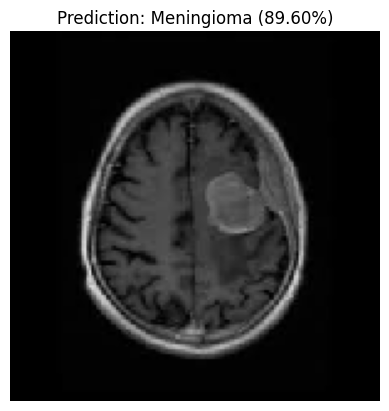

In [18]:
# Load & Preprocess image
img = load_img(img_path, target_size=(150,150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

#predict
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_index]
confidence = np.max(prediction) * 100

print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}")

plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

CONCLUSION

In this project, a Convolutional Neural Network (CNN) based model was developed to detect and classify brain tumors using MRI images. 
The CNN model successfully learned important features from MRI images and was able to classify the images into the correct categories with high accuracy. After training and evaluation, the model achieved a final accuracy of 96.34%, indicating strong performance in distinguishing between different types of brain tumors and normal brain images.

This project demonstrates that deep learning techniques, particularly CNNs, are highly effective for medical image classification tasks. The developed model can assist healthcare professionals by providing faster and more reliable predictions, which may help in early detection and treatment planning for brain tumor patients.Overall, the system shows promising results and highlights the potential of AI-powered diagnostic tools in improving the efficiency and accuracy of medical image analysis.